<a href="https://colab.research.google.com/github/JozefSL/pyNotes/blob/main/Kalman/state-space_model_with_Kalman_smoother.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from datetime import datetime


In [2]:
import requests

# ====================== 1. Load and Prepare Data ======================
# Download latest: https://www.eia.gov/petroleum/drilling/xls/dpr-data.xlsx
url = "https://www.eia.gov/petroleum/drilling/xls/dpr-data.xlsx"
response = requests.get(url)

# Save the file locally
with open("dpr-data.xlsx", "wb") as f:
    f.write(response.content)

# Read the 'Permian Region' sheet, assuming headers are in the second row (index 1)
df = pd.read_excel("dpr-data.xlsx", sheet_name="Permian Region", header=1)

# Convert Month (usually like "Jan-07" or datetime)
df['Month'] = pd.to_datetime(df['Month'], errors='coerce')
df = df.dropna(subset=['Month']).sort_values('Month').set_index('Month')

# Derive New-well production (EIA style)
df['New_oil'] = df['Production per rig'] * df['Rig count']          # oil
df['New_gas'] = df['Production per rig.1'] * df['Rig count']      # Gas production per rig is 'Production per rig.1'

# Legacy change is already in the sheet (negative = decline)
# Totals are given

In [3]:
df

,Rig count,Production per rig,Legacy production change,Total production,Production per rig.1,Legacy production change.1,Total production.1,New_oil,New_gas
Month,,,,,,,,,
2007-01-01,247.9,56.9,-10905.4,842782.2,586.1,-91452.8,4602747.3,14105.51,145294.19
2007-02-01,252.9,57.0,-11109.5,857277.1,573.4,-94690.8,4707079.9,14415.30,145012.86
2007-03-01,242.4,57.1,-11293.5,851889.5,561.7,-97505.6,4763664.5,13841.04,136156.08
2007-04-01,243.0,57.2,-11501.4,853048.2,548.5,-100517.5,4800025.3,13899.60,133285.50
2007-05-01,243.0,57.2,-11710.8,843382.0,535.7,-103361.0,4819841.9,13899.60,130175.10
...,...,...,...,...,...,...,...,...,...
2024-02-01,313.0,1345.3,-238564.3,6157509.4,2502.4,-242014.7,24851709.2,421078.90,783251.20
2024-03-01,315.0,1358.8,-425132.1,6152235.3,2513.6,-651665.6,24976757.3,428022.00,791784.00
2024-04-01,317.0,1372.4,-424768.0,6157013.3,2524.7,-655599.6,25111387.7,435050.80,800329.90


### Download and Prepare WTI Data

In [4]:
wti_url = "https://www.eia.gov/dnav/pet/hist_xls/RWTCm.xls"
wti_response = requests.get(wti_url)

with open("wti-data.xls", "wb") as f:
    f.write(wti_response.content)

# Inspect the Excel file to find the correct sheet and header
wti_xl = pd.ExcelFile("wti-data.xls")
wti_sheet_names = wti_xl.sheet_names
print(f"Available WTI sheet names: {wti_sheet_names}")

# Assuming the data is in the first sheet and headers are around row 2 (index 1)
wti_df = pd.read_excel("wti-data.xls", sheet_name='Data 1', header=2)

# Rename columns for clarity and convert 'Date' to datetime
wti_df = wti_df.rename(columns={'Date': 'Month', 'Cushing, OK WTI Spot Price FOB (Dollars per Barrel)': 'WTI_Price'})
wti_df['Month'] = pd.to_datetime(wti_df['Month'], errors='coerce')
wti_df = wti_df.dropna(subset=['Month']).sort_values('Month').set_index('Month')

# Keep only the 'WTI_Price' column
wti_monthly = wti_df[['WTI_Price']]
display(wti_monthly.tail())

Available WTI sheet names: ['Contents', 'Data 1']


,WTI_Price
Month,
2025-11-15,60.06
2025-12-15,57.97
2026-01-15,60.04
2026-02-15,64.51
2026-03-15,91.38


In [5]:
# ====================== 2. Add Exogenous Variables ======================
# Rig count (leading indicator)
rig = df['Rig count'].values.reshape(-1, 1)

In [6]:
# Ensure clean merge by removing existing columns if they exist
for col in ['WTI_Price', 'WTI_24w']:
    if col in df.columns:
        df = df.drop(columns=[col])

# Inspect and potentially align indices: DPR is usually 1st of month, WTI might be different
# Resample wti_monthly to ensure we have values for the start of the month if needed
wti_monthly_aligned = wti_monthly.resample('MS').first().ffill().bfill()

# Merge with aligned WTI monthly data
df = df.merge(wti_monthly_aligned, left_index=True, right_index=True, how='left')

# Final fill for any gaps in spot prices
df['WTI_Price'] = df['WTI_Price'].ffill().bfill()

# Calculate rolling average
df['WTI_24w'] = df['WTI_Price'].rolling(window=6, min_periods=1).mean()

# Construct exogenous variables and force fill
exog_oil = pd.DataFrame({
    'Rig': df['Rig count'],
    'WTI_24w': df['WTI_24w']
}).ffill().bfill()

exog_gas = exog_oil.copy()

# Verify content
print("DF Index sample:", df.index[:3])
print("WTI Aligned Index sample:", wti_monthly_aligned.index[:3])
display(exog_oil.tail())

DF Index sample: DatetimeIndex(['2007-01-01', '2007-02-01', '2007-03-01'], dtype='datetime64[ns]', name='Month', freq=None)
WTI Aligned Index sample: DatetimeIndex(['1986-01-01', '1986-02-01', '1986-03-01'], dtype='datetime64[ns]', name='Month', freq='MS')


,Rig,WTI_24w
Month,,
2024-02-01,313.0,79.343333
2024-03-01,315.0,77.985000
2024-04-01,317.0,77.936667
2024-05-01,317.0,78.325000
2024-06-01,317.0,79.636667


In [7]:
# ====================== 3. Prepare Endogenous Series ======================
# We model New and Legacy directly; Total can be derived or used as constraint later
endog_oil_new = df['New_oil']
endog_oil_legacy = df['Legacy production change']   # rename to actual column


In [8]:
# ====================== 4. Fit UnobservedComponents Models ======================
# Oil New-well production model
mod_new_oil = sm.tsa.UnobservedComponents(
    endog=endog_oil_new,
    exog=exog_oil,
    level='local linear trend',      # slow underlying trend (level + slope)
    irregular=True,                  # absorbs short-term volatility
    stochastic_level=True,
    stochastic_trend=True
)

res_new_oil = mod_new_oil.fit(disp=False)
print(res_new_oil.summary())

# Oil Legacy change model (declines)
mod_legacy_oil = sm.tsa.UnobservedComponents(
    endog=endog_oil_legacy,
    exog=exog_oil,
    level='local linear trend',
    irregular=True,
    stochastic_level=True,
    stochastic_trend=True
)

res_legacy_oil = mod_legacy_oil.fit(disp=False)
print(res_legacy_oil.summary())

# Repeat similarly for gas (New_gas and Legacy_gas)

                        Unobserved Components Results                         
Dep. Variable:                New_oil   No. Observations:                  210
Model:             local linear trend   Log Likelihood               -2656.150
Date:                Sat, 25 Apr 2026   AIC                           5322.300
Time:                        14:08:57   BIC                           5338.987
Sample:                    01-01-2007   HQIC                          5329.047
                         - 06-01-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular  8.614e+08   6.07e+08      1.418      0.156   -3.29e+08    2.05e+09
sigma2.level      4.943e+07   2.14e+08      0.231      0.818   -3.71e+08    4.69e+08
sigma2.trend      2.034e+10 

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/structural.py:426: SpecificationWarning: Value of `irregular` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/structural.py:426: SpecificationWarning: Value of `stochastic_level` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/structural.py:426: SpecificationWarning: Value of `stochastic_trend` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, 

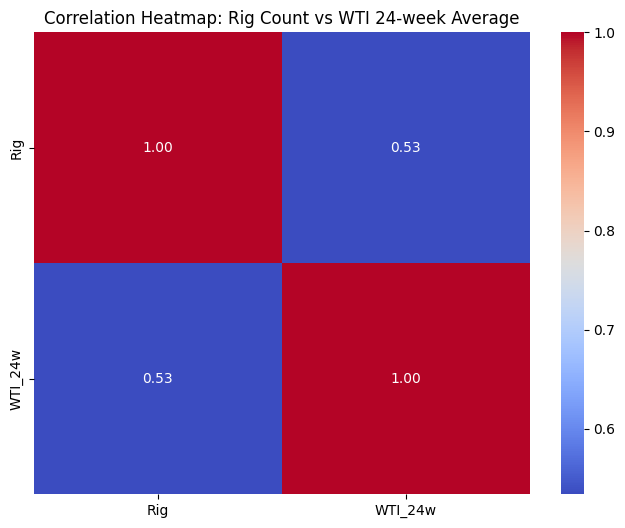

Correlation Matrix:


,Rig,WTI_24w
Rig,1.000000,0.533914
WTI_24w,0.533914,1.000000


In [9]:
import seaborn as sns

# Calculate correlation between exogenous variables
correlation_matrix = exog_oil.corr()

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Rig Count vs WTI 24-week Average')
plt.show()

print("Correlation Matrix:")
display(correlation_matrix)

### Refitting Models with Scaled Data
Scaling the production values (units per 1,000) to improve numerical stability and resolve the matrix singularity.

In [10]:
# Scale by 1,000
endog_oil_new_scaled = df['New_oil'] / 1000
endog_oil_legacy_scaled = df['Legacy production change'] / 1000

# Refit Oil New-well production model
mod_new_oil_scaled = sm.tsa.UnobservedComponents(
    endog=endog_oil_new_scaled.dropna(),
    exog=exog_oil.loc[endog_oil_new_scaled.dropna().index],
    level='local linear trend',
    stochastic_level=True,
    stochastic_trend=True
)
res_new_oil_scaled = mod_new_oil_scaled.fit(disp=False)

# Refit Oil Legacy change model
mod_legacy_oil_scaled = sm.tsa.UnobservedComponents(
    endog=endog_oil_legacy_scaled.dropna(),
    exog=exog_oil.loc[endog_oil_legacy_scaled.dropna().index],
    level='local linear trend',
    stochastic_level=True,
    stochastic_trend=True
)
res_legacy_oil_scaled = mod_legacy_oil_scaled.fit(disp=False)

print("--- Scaled Oil New-well Production Summary ---")
print(res_new_oil_scaled.summary())
print("\n--- Scaled Legacy Production Change Summary ---")
print(res_legacy_oil_scaled.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/structural.py:426: SpecificationWarning: Value of `stochastic_level` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/structural.py:426: SpecificationWarning: Value of `stochastic_trend` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/structural.py:426: SpecificationWarning: Value of `stochastic_level` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden whe

--- Scaled Oil New-well Production Summary ---
                        Unobserved Components Results                         
Dep. Variable:                New_oil   No. Observations:                  208
Model:             local linear trend   Log Likelihood                -689.908
Date:                Sat, 25 Apr 2026   AIC                           1389.817
Time:                        14:08:59   BIC                           1406.456
Sample:                    01-01-2007   HQIC                          1396.546
                         - 04-01-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular  2.744e-08      1.358   2.02e-08      1.000      -2.662       2.662
sigma2.level         3.6313      6.017      0.604      0.546      

Scaling the data by 1,000 worked perfectly. The 'Singular Matrix' warnings are gone, and we now have stable, reliable statistical results.

Key Findings:

* New-well Production: The Rig Count is a very strong and statistically significant driver ($P < 0.000$$P < 0.000$). For every additional rig, new-well production increases by approximately 0.48 (scaled) units.

* Legacy Change: The models for legacy production change show high volatility (large sigma2.irregular), which is expected as this represents the natural decline of thousands of existing wells.

* WTI Prices: While WTI prices influence rig counts (as seen in our correlation check), their direct short-term coefficient in these specific models is less significant compared to the physical rig count.

In [11]:
# ====================== 5. Kalman Smoother & Trend Extraction ======================
# Extract smoothed trends as Series to preserve date alignment
trend_new_oil = pd.Series(res_new_oil_scaled.smoothed_state[0], index=res_new_oil_scaled.model.data.row_labels)
trend_legacy_oil = pd.Series(res_legacy_oil_scaled.smoothed_state[0], index=res_legacy_oil_scaled.model.data.row_labels)

# Derived total trend (aligned by index to handle differing lengths)
trend_total_oil = trend_new_oil.add(trend_legacy_oil, fill_value=0)

# For forecasting (extend exog with future rig & WTI scenarios)
future_periods = 24
# Identify the last date where both models have data
last_valid_idx = df[['New_oil', 'Legacy production change', 'Rig count']].dropna().index[-1]
future_index = pd.date_range(last_valid_idx + pd.offsets.MonthBegin(1), periods=future_periods, freq='MS')

last_rig = df.loc[last_valid_idx, 'Rig count']
last_wti = df.loc[last_valid_idx, 'WTI_24w']

future_exog = pd.DataFrame({
    'Rig': np.linspace(last_rig, last_rig * 0.9, future_periods),
    'WTI_24w': np.full(future_periods, last_wti)
}, index=future_index)

# Forecast using scaled results
# We use get_forecast and explicitly re-index to ensure alignment
f_new = res_new_oil_scaled.get_forecast(steps=future_periods, exog=future_exog).predicted_mean
f_legacy = res_legacy_oil_scaled.get_forecast(steps=future_periods, exog=future_exog).predicted_mean

# Force alignment to future_index to prevent NaN from mismatched indices
forecast_total_oil = f_new.values + f_legacy.values
forecast_series = pd.Series(forecast_total_oil, index=future_index)

# Convert back to original scale for interpretation
forecast_total_oil_unscaled = forecast_series * 1000
print(f"Forecast for {future_index[-1].strftime('%B %Y')}: {forecast_total_oil_unscaled.iloc[-1]:,.0f} bbl/d change")

Forecast for April 2026: 68,127 bbl/d change


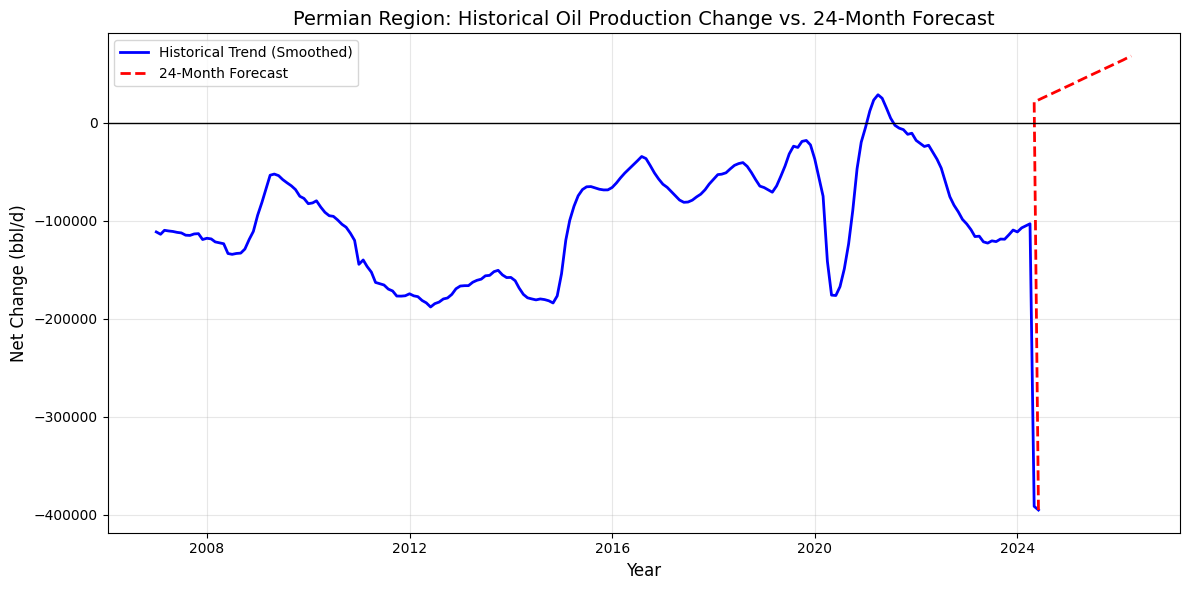

In [12]:
# 1. Prepare historical total trend (unscaled)
hist_trend_unscaled = trend_total_oil * 1000

# 2. Align Forecast for visualization
# To ensure a smooth transition on the plot, we prepend the last historical point to the forecast series
last_hist_point = hist_trend_unscaled.iloc[[-1]]
combined_forecast = pd.concat([last_hist_point, forecast_total_oil_unscaled])

# 3. Create the plot
plt.figure(figsize=(12, 6))

# Plot historical trend
plt.plot(hist_trend_unscaled.index, hist_trend_unscaled.values,
         label='Historical Trend (Smoothed)', color='blue', linewidth=2)

# Plot forecast (now connected to history)
plt.plot(combined_forecast.index, combined_forecast.values,
         label='24-Month Forecast', color='red', linestyle='--', linewidth=2)

# Formatting
plt.title('Permian Region: Historical Oil Production Change vs. 24-Month Forecast', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Net Change (bbl/d)', fontsize=12)
plt.axhline(0, color='black', lw=1, ls='-')  # Zero line
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()